In [1]:
# 16 March 2025
# Zachary Katz
# zachary_katz@mines.edu

"""
Doppler width plot (spatial freq corrected for helicopter velocity) and crossover
analysis.

"""

# Imports and options
import os

import shapefile
import numpy as np
import xarray as xr
import scipy
import skimage

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs
import matplotlib.patheffects as pe
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit

%matplotlib inline

### MANUALLY SELECTED PARAMETERS ###
win_m = 750.0 # window length [m]
ovlp_m = 250.0 # overlap [m]

In [15]:
# Set paths and make output directory
offset_video_path_1819 = '../_Data/UTG_1819_OffsetVideo'
offset_video_path_1617 = '../_Data/UTG_1617_OffsetVideo'
lake_path = '../_Data/Ju_SLD2'
outdir = '.'
os.makedirs(outdir, exist_ok=True)

# Helper functions
def compute_doppler_spectrum(radargram, start_x,end_x):
    """
    Compute doppler spectrum of radargram using hilbert transform.

    Parameters
    ----------
    radargram : Xarray.Dataframe
        UTIG radargram offset video

    Returns
    -------
    doppler_spectrum : np.ndarray
        2D array of doppler spectrum 
    """
    
    # Example coordinates at the bed
    start_y = 1100
    end_y = 1800

    x_at = radargram['x'].compute().values  # meters
    x_at = x_at[:]
    y_at = radargram['y'].compute().values  # meters
    y_at = y_at[:]

    x_center = np.mean(x_at[start_x:end_x])
    y_center = np.mean(y_at[start_x:end_x])

    # Get low gain band
    dat = radargram['bxds2'].compute().astype(np.float32)
    
    # Hilbert along fast_time axis
    analytic = scipy.signal.hilbert(dat, axis=1)
    data = analytic.T

    # Fast fourier transform
    data_for_fft = data[start_y:end_y:,start_x:end_x]
    data_fft = np.fft.fftshift(np.fft.fft(data_for_fft, axis=1), axes=1)

    # Make frequency axis
    t = radargram['time'] 
    t_sec = (t - t[0]).astype('timedelta64[ns]').astype(np.float64) * 1e-9
    dt_slow = np.median(np.diff(t_sec.compute()))
    n_slow = data.shape[1]
    freq = np.fft.fftshift(
        np.fft.fftfreq(n_slow, d=dt_slow)
    )
    return freq, data_fft, start_y, end_y, x_center, y_center

def calc_doppler_ridge(freq, data_fft, start_y, end_y):
    """Use a Sato filter to extract the main band of a doppler spectrum.

    Parameters
    ----------
    freq : numpy.ndarray
        Frequency axis values of Fourier transform
    data_fft : numpy.ndarray
        2D fourier transform output
    start_y : float
        Starting y value of Fourier transform
    end_y : float
        Ending y value of Fourier transform

    Returns
    -------
    x : numpy.ndarray
        x-values of filtered maximum points at each frequency
    y : numpy.ndarray
        y-values of filtered maximum points at each frequency
    rad_db_sato : numpy.ndarray
        Sato-filtered and masked spectrum
    """

    # Transform radargram to log scale
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    # Filter for main band of spectrum and mask
    rad_db = scipy.ndimage.gaussian_filter(rad_db, sigma=(3,2))
    rad_db = skimage.filters.sato(rad_db, sigmas=range(10,15), black_ridges=False)
    mask = rad_db > (skimage.filters.threshold_otsu(rad_db))
    rad_db_sato = rad_db * mask

    max_indices = np.argmax(rad_db_sato, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])
    return x, start_y + max_indices, rad_db_sato

def calc_width_and_max(x,y,threshold):
    """
    Find width and max of Sato-filtered doppler spectra.
    Start with y location of middle point, assumed to be in the main parabola 
    [valid unless severely sloping]. Work out in both directions until distance
    between point and prior point is greater than a threshold

    Parameters
    ----------
    x : numpy.ndarray
        x-values of filtered maximum points at each frequency
    y : numpy.ndarray
        y-values of filtered maximum points at each frequency
    threshold : float
        Gap tolerance in algorithm [ns]

    Returns
    -------
    x[right] : float
        Right edge x-value
    x[left] : float
        Left edge x-value
    x_at_max : float
        x-value at maximum y
    y_at_max : float
        Maximum y-value
    """

    y = -y # Flip direction convention (Depth increases downward)
    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Find right edge
    threshold = 100  # ns
    diff = 0
    while (diff < threshold) and (starting_index < len(y)-1):
        next_index = starting_index + 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    right = (starting_index - 1)

    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Find left edge
    threshold = 100  # ns
    diff = 0
    while (diff < threshold) and (starting_index > 0):
        next_index = starting_index - 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    left = (starting_index + 1)

    y_masked = y[left:right]
    
    # Return nan if no max found
    try:
        y_at_max = -np.max(y_masked)
        x_at_max = x[np.argmax(y_masked) + left]
    except:
        y_at_max = np.nan
        x_at_max = np.nan

    return x[right],x[left], x_at_max, y_at_max

def plot_doppler(freq, data_fft, start_y, end_y, ridge_params, rad_db_sato):
    """
    Plot doppler spectrum and Sato-filtered doppler spectrum with max and width
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Get doppler spectrum in dB
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    # Plot doppler spectrum
    im1 = ax1.imshow(rad_db, aspect='auto', cmap='gray', origin='lower', extent = [freq[0], freq[-1],start_y, end_y], vmin=-50, vmax=0)
    # Prettify ax1
    ax1.invert_yaxis()
    cb1 = fig.colorbar(im1, ax=ax1)
    ax1.set_ylabel("Fast Time [ns]",fontsize=16)
    ax1.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax1.tick_params(labelsize=14)
    cb1.ax.tick_params(labelsize=14)
    cb1.set_label("Amplitude [dB]", fontsize=16)

    # Plot Sato-filtered doppler spectrum
    im2 = ax2.imshow(rad_db_sato,aspect='auto', cmap='gray',origin='lower',extent = [freq[0], freq[-1],start_y, end_y])
   
    # Scatter maximum and width
    
    max_indices = np.argmax(rad_db_sato, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])
    ax2.scatter(x, start_y + max_indices, color='red', s=10, marker='x')
    ax2.scatter(ridge_params['x_at_max'], ridge_params['y_at_max'], color='blue', s=100, marker='o')
    ax2.hlines(ridge_params['y_at_max'], ridge_params['left'], ridge_params['right'], colors='blue', linestyles='-', linewidth=2)
    
    # Prettify ax2
    ax2.invert_yaxis()
    cb2 = fig.colorbar(im2, ax=ax2, label="Amplitude [dB]")
    fig.tight_layout()
    ax2.set_ylabel("Fast Time [ns]",fontsize=16)
    ax2.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax2.tick_params(labelsize=14)
    cb2.ax.tick_params(labelsize=14)
    cb2.set_label("Sato [Thresholded]", fontsize=16)

    fig.tight_layout()
    return fig


def plot_radargram_planview_width(ax, xs_lake, ys_lake, plot_dict):
    """
    Plot doppler width and lake outline map view
    """

    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

    # Remove borders
    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for x_center_list, y_center_list, plotting in zip(plot_dict['x_centers'], plot_dict['y_centers'], plot_dict['ridge_params_list']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        cb = ax.scatter(x_center_list, y_center_list, c=width, cmap='viridis', s=30, zorder=4,vmin=0,vmax=25)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

    # Add colorbar
    k_cbar_anchor = (0,0)
    cbbox = inset_axes(ax, width=3,height=1,
                    bbox_to_anchor=k_cbar_anchor,
                    bbox_transform=ax.transAxes, loc="center left")
    [cbbox.spines[k].set_visible(False) for k in cbbox.spines]
    cbbox.tick_params(
        axis = 'both',
        left = False,
        top = False,
        right = False,
        bottom = False,
        labelleft = False,
        labeltop = False,
        labelright = False,
        labelbottom = False
    )
    cbbox.set_facecolor([0,0,0,0.9])

    cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
    cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
    cbar.outline.set_edgecolor('white')
    cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
    cbar.set_label(r"Spatial Freq Width [m$^{-1}$]", fontsize=15, color='white')
    cbar.ax.xaxis.set_label_position('top')

    cbar.ax.minorticks_on()

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])
    #ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)

    return fig

In [3]:
# Load KRT2 offset video netcdf files

file_paths_1819 = [os.path.join(offset_video_path_1819, f) for f in os.listdir(offset_video_path_1819) if f.endswith('.nc')]
file_paths_1617 = [os.path.join(offset_video_path_1617, f) for f in os.listdir(offset_video_path_1617) if f.endswith('.nc')]

offset_video_radargrams_1819 = []
for f in file_paths_1819:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1819.append(offset_video_radargram)

offset_video_radargrams_1819.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1819[0]

offset_video_radargrams_1617 = []
for f in file_paths_1617:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1617.append(offset_video_radargram)

offset_video_radargrams_1617.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1617[0]

len(offset_video_radargrams_1819), len(offset_video_radargrams_1617)


(42, 11)

In [4]:
# Set up plan view plotting function
def plot_radargram_planview(ax, radargrams, xs_lake, ys_lake):
    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full

    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for radargram in radargrams[:]:
        ax.plot(radargram.x, radargram.y, color='gainsboro', zorder=3, transform=ps71_projection,linewidth=1,alpha=0.7)
        #print(radargram.transect_id.split('/')[-1])
        if radargram.transect_id.split('/')[-1] == rad_no:
            ax.text(radargram.x[0], radargram.y[0], radargram.transect_id.split('/')[-1], color='red', fontsize=15, transform=ps71_projection, zorder=5)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='blue', linewidth=1, zorder=0, alpha=0.4)
    ax.scatter(seismic['Shot_X'], seismic['Shot_Y'], s=1, c='black', label='Seismic Shots', transform=ps71_projection)
    # Add red where X26a from 10000m to 15000m along track
    msk = (test_rad['distance'] >= start_x) & (test_rad['distance'] <= end_x)
    ax.plot(test_rad['x'].where(msk), test_rad['y'].where(msk), color='red', linewidth=2, zorder=4, transform=ps71_projection)
    # Plot meters at 10000 and 15000 along track
    # Find closest points to 10000 and 15000
    met_x1 = test_rad['x'].sel(distance=start_x, method='nearest').values
    met_y1 = test_rad['y'].sel(distance=start_x, method='nearest').values
    met_x2 = test_rad['x'].sel(distance=end_x, method='nearest').values
    met_y2 = test_rad['y'].sel(distance=end_x, method='nearest').values
    print(met_x1, met_y1, met_x2, met_y2)
    ax.text(met_x1 -1500, met_y1 +500, f'{start_x} m', color='red', fontsize=14, transform=ps71_projection, zorder=6,ha='left')
    ax.text(met_x2 + 2000, met_y2 -1000, f'{end_x} m', color='red', fontsize=14, transform=ps71_projection, zorder=6,ha='right')
    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])

In [5]:
import pandas as pd
from pyproj import CRS, Transformer

def ll2xy(lon: list[float], lat: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y).
    Can also take single floats.

    Parameters
    ----------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326

    Returns
    -------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y


In [6]:
# Load Subglacial Lake Cheongsuk shapefile
pathA = lake_path + '/SLD2-A.shp'
pathB = lake_path + '/SLD2-B.shp'
pathC = lake_path + '/SLD2-C.shp'

xs_lake = []
ys_lake = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs_lake.append(x)
    ys_lake.append(y)


In [7]:
# TODO: Refactor storage method to avoid lists of lists!

# Loop over radargrams, loop over windows, and compute specularity
plotting_dict = {'x_centers':[], 'y_centers':[],'ridge_params_list':[]}
for radargram in offset_video_radargrams_1617[:]:
    print(radargram.transect_id)
    # Extract hilbert transform and low gain band
    dat = radargram['bxds2'].compute().astype(np.float32)
    analytic = scipy.signal.hilbert(dat, axis=1)
    data = analytic.T

    # Compute frequency axis
    x_at = radargram['distance'].compute().values  # meters
    dx = np.median(np.diff(x_at))
    
    win_n = int(win_m / dx)
    step_n = int((win_m - ovlp_m) / dx)

    dt_slow = np.median(np.diff((radargram['time'] - radargram['time'][0]).astype('timedelta64[ns]').astype(np.float64).compute())) * 1e-9
    freq = np.fft.fftshift(np.fft.fftfreq(win_n, d=dt_slow))

    # Chose y range that encompasses bed and in y
    start_y = 1100
    end_y = 1800
    data_for_plot = data[start_y:end_y:,:]
    dist_at = radargram['distance'].compute().values  # meters
    dist_at = dist_at[:]
    x_at = radargram['x'].compute().values  # meters
    x_at = x_at[:]
    y_at = radargram['y'].compute().values  # meters
    y_at = y_at[:]
    data = data_for_plot - np.mean(data_for_plot, axis=0, keepdims=True)
    window = scipy.signal.windows.hann(win_n)

    # Lists of variables to save for each window
    doppler_cubes = []     # list of [range, doppler]
    x_centers = []         # along-track center positions, x
    y_centers = []         # along-track center positions, y

    # Loop over slow-time windows and compute doppler spectra
    for start in range(0, data.shape[1] - win_n + 1, step_n):
        stop = start + win_n
        # Crop in x amd fourier transform
        data_win = data[:, start:stop]
        data_win = data_win * window[None, :]
        fft_win = np.fft.fftshift(np.fft.fft(data_win, axis=1),axes=1)

        # Store results
        doppler_cubes.append(fft_win)
        x_centers.append(np.mean(x_at[start:stop]))
        y_centers.append(np.mean(y_at[start:stop]))

    # Compute resulting doppler spectra widths and maximums
    ridge_params_list = []
    for cube in doppler_cubes[:]:
        x_sato, y_sato, sato_thresholded = calc_doppler_ridge(freq, cube, start_y, end_y)
        right, left, x_at_max, y_at_max = calc_width_and_max(x_sato, y_sato, threshold=100)
        
        # Store results
        ridge_params = {'right':right, 'left':left, 'x_at_max':x_at_max, 'y_at_max':y_at_max}
        ridge_params_list.append(ridge_params)

    # Store as ragged array of arrays: 1st layer length = number of radargrams, 2nd layer length =numbers windows per radargram
    plotting_dict['x_centers'].append(x_centers)
    plotting_dict['y_centers'].append(y_centers)
    plotting_dict['ridge_params_list'].append(ridge_params_list)

DVG/IBH0c/GL0173a
DVG/IBH0c/GL0292d
DVG/IBH0c/GL0700a
DVG/IBH0c/GL0819a
DVG/IBH0c/GL1191a
DVG/IBH0c/X22a
DVG/IBH0c/X23a
DVG/IBH0c/X24a
DVG/IBH0c/X25a
DVG/IBH0c/X26a
DVG/IBH0c/X27a


In [8]:
# TODO: Refactor storage method to avoid lists of lists!

# Loop over radargrams, loop over windows, and compute specularity
plotting_dict_1819 = {'x_centers':[], 'y_centers':[],'ridge_params_list':[]}
for radargram in offset_video_radargrams_1819[:]:
    # Check and remove X21b and X27b
    if not any(x in radargram.transect_id for x in ['X21b', 'X27b']):
        print(radargram.transect_id)
        # Extract hilbert transform and low gain band
        dat = radargram['bxds2'].compute().astype(np.float32)
        analytic = scipy.signal.hilbert(dat, axis=1)
        data = analytic.T

        # Compute frequency axis
        x_at = radargram['distance'].compute().values  # meters
        dx = np.median(np.diff(x_at))
        
        win_n = int(win_m / dx)
        step_n = int((win_m - ovlp_m) / dx)

        dt_slow = np.median(np.diff((radargram['time'] - radargram['time'][0]).astype('timedelta64[ns]').astype(np.float64).compute())) * 1e-9
        freq = np.fft.fftshift(np.fft.fftfreq(win_n, d=dt_slow))

        # Chose y range that encompasses bed and in y
        start_y = 1100
        end_y = 1800
        data_for_plot = data[start_y:end_y:,:]
        dist_at = radargram['distance'].compute().values  # meters
        dist_at = dist_at[:]
        x_at = radargram['x'].compute().values  # meters
        x_at = x_at[:]
        y_at = radargram['y'].compute().values  # meters
        y_at = y_at[:]
        data = data_for_plot - np.mean(data_for_plot, axis=0, keepdims=True)
        window = scipy.signal.windows.hann(win_n)

        # Lists of variables to save for each window
        doppler_cubes = []     # list of [range, doppler]
        x_centers = []         # along-track center positions, x
        y_centers = []         # along-track center positions, y

        # Loop over slow-time windows and compute doppler spectra
        for start in range(0, data.shape[1] - win_n + 1, step_n):
            stop = start + win_n
            # Crop in x amd fourier transform
            data_win = data[:, start:stop]
            data_win = data_win * window[None, :]
            fft_win = np.fft.fftshift(np.fft.fft(data_win, axis=1),axes=1)

            # Store results
            doppler_cubes.append(fft_win)
            x_centers.append(np.mean(x_at[start:stop]))
            y_centers.append(np.mean(y_at[start:stop]))

        # Compute resulting doppler spectra widths and maximums
        ridge_params_list = []
        for cube in doppler_cubes[:]:
            x_sato, y_sato, sato_thresholded = calc_doppler_ridge(freq, cube, start_y, end_y)
            right, left, x_at_max, y_at_max = calc_width_and_max(x_sato, y_sato, threshold=100)
            
            # Store results
            ridge_params = {'right':right, 'left':left, 'x_at_max':x_at_max, 'y_at_max':y_at_max}
            ridge_params_list.append(ridge_params)

        # Store as ragged array of arrays: 1st layer length = number of radargrams, 2nd layer length =numbers windows per radargram
        plotting_dict_1819['x_centers'].append(x_centers)
        plotting_dict_1819['y_centers'].append(y_centers)
        plotting_dict_1819['ridge_params_list'].append(ridge_params_list)

D2DG/IBH0e/X10a
D2DG/IBH0e/X11a
D2DG/IBH0e/X12a
D2DG/IBH0e/X13a
D2DG/IBH0e/X14a
D2DG/IBH0e/X15a
D2DG/IBH0e/X17a
D2DG/IBH0e/X18a
D2DG/IBH0e/X19a
D2DG/IBH0e/X20a
D2DG/IBH0e/X21a
D2DG/IBH0e/X22a
D2DG/IBH0e/X23a
D2DG/IBH0e/X24a
D2DG/IBH0e/X25a
D2DG/IBH0e/X26a
D2DG/IBH0e/X27a
D2DG/IBH0e/X28a
D2DG/IBH0e/X29a
D2DG/IBH0e/X30a
D2DG/IBH0e/X31a
D2DG/IBH0e/X32a
D2DG/IBH0e/X33a
D2DG/IBH0e/X34a
D2DG/IBH0e/X35a
D2DG/IBH0e/X37a
D2DG/IBH0g/Y22a
D2DG/IBH0g/Y23a
D2DG/IBH0g/Y24a
D2DG/IBH0g/Y25a
D2DG/IBH0g/Y26a
D2DG/IBH0g/Y27a
D2DG/IBH0g/Y28a
D2DG/IBH0g/Y29a
D2DG/IBH0g/Y30a
D2DG/IBH0g/Y31a
D2DG/IBH0g/Y32a
D2DG/IBH0g/Y33a
D2DG/IBH0g/Y34a
D2DG/IBH0g/Y35a


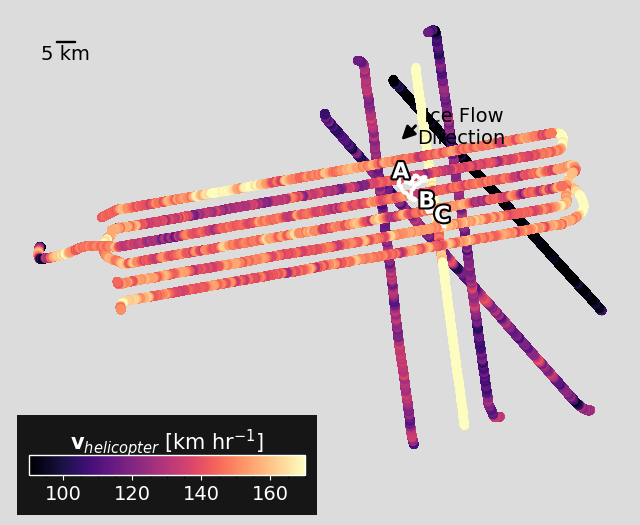

In [10]:
# Convert from spatial freq width to doppler width
MS_TO_KMHR = 3.6
for radargram in offset_video_radargrams_1819[:]:
    avg_distance = np.mean(np.diff(radargram['distance'].values))

    time = (radargram['time'][-1] - radargram['time'][0])
    time = time / np.timedelta64(1, 's')
    
    velocity = (radargram['distance'][-1] - radargram['distance'][0]).values / time #m/s
    radargram['avg_velocity']  = velocity

    dt = np.gradient(radargram.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
    dd = np.gradient(radargram.distance.values) # meters
    radargram['velocity'] = (('distance',), dd/ dt * MS_TO_KMHR)

for radargram in offset_video_radargrams_1617[:]:
    avg_distance = np.mean(np.diff(radargram['distance'].values))

    time = (radargram['time'][-1] - radargram['time'][0])
    time = time / np.timedelta64(1, 's')
    
    velocity = (radargram['distance'][-1] - radargram['distance'][0]).values / time #m/s
    radargram['avg_velocity']  = velocity

    dt = np.gradient(radargram.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
    dd = np.gradient(radargram.distance.values) # meters
    radargram['velocity'] = (('distance',), dd/ dt * MS_TO_KMHR)



# Plot velocities
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

# Remove borders
ax.patch.set_facecolor("none")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

for x, y in zip(xs_lake, ys_lake):
    ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

# Add colorbar
k_cbar_anchor = (0,0)
cbbox = inset_axes(ax, width=3,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax.transAxes, loc="center left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.9])

for radargram in offset_video_radargrams_1617[:]:
    #if 'Y' in radargram.transect_id.split('/')[-1]:
    cb = ax.scatter(radargram['x'],radargram['y'] , c=radargram['velocity'], cmap='magma', s=30, zorder=4,vmin=90,vmax=170)
cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"$\mathbf{v}_{helicopter}$ [km hr$^{-1}$]", fontsize=15, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
#ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)


# Lakeb lakes A, B, C
ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')


In [24]:
# Remove radargram.transect_id for x in ['X21b', 'X27b'] from offsert_video_radargrams_1819
offset_video_radargrams_1819 = [rg for rg in offset_video_radargrams_1819 if not any(x in rg.transect_id for x in ['X21b', 'X27b'])]

In [27]:
# Scale by velocity
# Convert from spatial freq width to doppler width

MS_TO_KMHR = 3.6
for radargram in offset_video_radargrams_1819[:]:
    avg_distance = np.mean(np.diff(radargram['distance'].values))

    time = (radargram['time'][-1] - radargram['time'][0])
    time = time / np.timedelta64(1, 's')
    
    velocity = (radargram['distance'][-1] - radargram['distance'][0]).values / time #m/s
    radargram['avg_velocity']  = velocity

    dt = np.gradient(radargram.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
    dd = np.gradient(radargram.distance.values) # meters
    radargram['velocity'] = (('distance',), dd/ dt) # m/s

for radargram in offset_video_radargrams_1617[:]:
    avg_distance = np.mean(np.diff(radargram['distance'].values))

    time = (radargram['time'][-1] - radargram['time'][0])
    time = time / np.timedelta64(1, 's')
    
    velocity = (radargram['distance'][-1] - radargram['distance'][0]).values / time #m/s
    radargram['avg_velocity']  = velocity

    dt = np.gradient(radargram.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
    dd = np.gradient(radargram.distance.values) # meters
    radargram['velocity'] = (('distance',), dd/ dt) # m/s

In [ ]:
velocities_1819 = []
for radargram, center_list in zip(offset_video_radargrams_1819[:], plotting_dict_1819['x_centers'][:]):
    velocities = []
    
    for center in center_list[:]:
        idx = np.argmin(np.abs(radargram['x'].compute().values - center))
        velocities.append(radargram['velocity'][idx].values)
    
    velocities_1819.append(velocities)
  
velocities_1617 = []
for radargram, center_list in zip(offset_video_radargrams_1617[:], plotting_dict['x_centers'][:]):
    velocities = []
    
    for center in center_list[:]:
        idx = np.argmin(np.abs(radargram['x'].compute().values - center))
        velocities.append(radargram['velocity'][idx].values)
    
    velocities_1617.append(velocities)  

plotting_dict_1819['velocities'] = velocities_1819
plotting_dict['velocities'] = velocities_1617

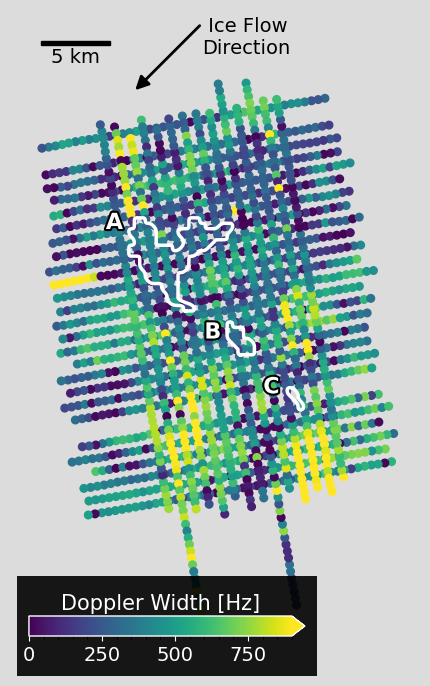

In [70]:
# Plot plan view comparison, scaled by velocity
def plot_radargram_planview_width_velocity(ax, xs_lake, ys_lake, plot_dict, rad_vel):
    """
    Plot doppler width and lake outline map view
    """

    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

    # Remove borders
    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    velocities = [rad['avg_velocity'] for rad in rad_vel[:]]
    for x_center_list, y_center_list, plotting,velocity in zip(plot_dict['x_centers'], plot_dict['y_centers'], plot_dict['ridge_params_list'],velocities):
        width = [rp['right'] - rp['left'] for rp in plotting]
        scaled_width = [w * velocity for w in width]  # Scale by velocity to get doppler width
        #print(min(scaled_width), max(scaled_width))
        cb = ax.scatter(x_center_list, y_center_list, c=scaled_width, cmap='viridis', s=30, zorder=4,vmin=0,vmax=900)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

    # Add colorbar
    k_cbar_anchor = (0,0)
    cbbox = inset_axes(ax, width=3,height=1,
                    bbox_to_anchor=k_cbar_anchor,
                    bbox_transform=ax.transAxes, loc="center left")
    [cbbox.spines[k].set_visible(False) for k in cbbox.spines]
    cbbox.tick_params(
        axis = 'both',
        left = False,
        top = False,
        right = False,
        bottom = False,
        labelleft = False,
        labeltop = False,
        labelright = False,
        labelbottom = False
    )
    cbbox.set_facecolor([0,0,0,0.9])

    cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
    cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
    cbar.outline.set_edgecolor('white')
    cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
    cbar.set_label(r"Doppler Width [Hz]", fontsize=15, color='white')
    cbar.ax.xaxis.set_label_position('top')

    cbar.ax.minorticks_on()

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])
    #ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)

    return fig


ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

plot_radargram_planview_width_velocity(ax, xs_lake, ys_lake, plotting_dict_1819, offset_video_radargrams_1819)
scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

# Lakeb lakes A, B, C
ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')

fig.savefig(os.path.join(outdir, 'Doppler_width_map.png'), dpi=300, bbox_inches='tight')



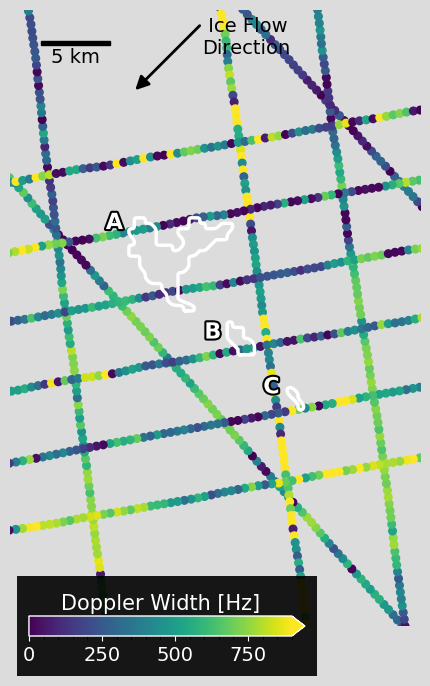

In [72]:
# 1617 Scaled by velocity
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

plot_radargram_planview_width_velocity(ax, xs_lake, ys_lake, plotting_dict, offset_video_radargrams_1617)
scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

# Lakeb lakes A, B, C
ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')

fig.savefig(os.path.join(outdir, 'Doppler_width_map.png'), dpi=300, bbox_inches='tight')


In [94]:
# Plot difference

# Find points within 100 km of each other in the two datasets
coords_1819 = np.column_stack((
    np.concatenate(plotting_dict_1819['x_centers']),
    np.concatenate(plotting_dict_1819['y_centers'])
))

coords_1617 = np.column_stack((
    np.concatenate(plotting_dict['x_centers']),
    np.concatenate(plotting_dict['y_centers'])
))

ridge_params_1819 = [r for sublist in plotting_dict_1819['ridge_params_list'] for r in sublist]
ridge_params_1617 = [r for sublist in plotting_dict['ridge_params_list'] for r in sublist]

# Compute width (abs(left-right)) for each sub-point
width_1819 = np.array([abs(r['left'] - r['right']) for r in ridge_params_1819])
width_1617 = np.array([abs(r['left'] - r['right']) for r in ridge_params_1617])

# Compute scaled_width by multiplying by velocity
width_velocity_scaled_1819 = np.concatenate(velocities_1819) * width_1819
width_velocity_scaled_1617 = np.concatenate(velocities_1617) * width_1617

print(len(plotting_dict_1819['x_centers']))
print(len(plotting_dict_1819['y_centers']))
print(len(plotting_dict['x_centers']))
print(len(plotting_dict['y_centers']))
print(len(width_1819))
print(len(width_1617))
print(len(width_velocity_scaled_1819))
print(len(width_velocity_scaled_1617))

tree_1617 = cKDTree(coords_1617)

dist, idx = tree_1617.query(coords_1819)

mask = dist <= 500

matched_coords = coords_1819[mask]
ridge_diff = width_1819[mask] - width_1617[idx[mask]]
ridge_diff_velocity_scaled = width_velocity_scaled_1819[mask] - width_velocity_scaled_1617[idx[mask]]


40
40
11
11
2024
2675
2024
2675


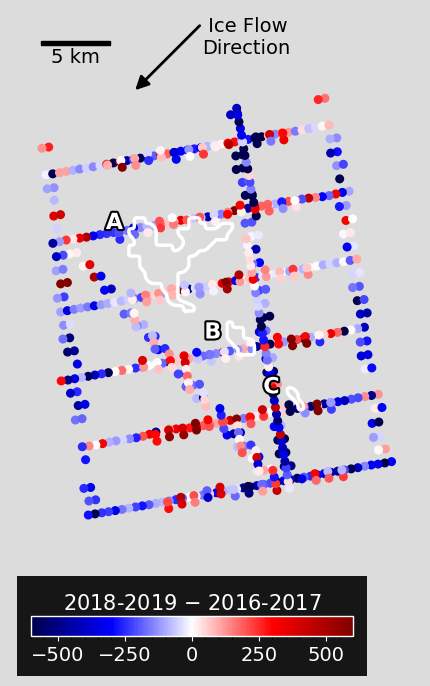

In [99]:
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

# Remove borders
ax.patch.set_facecolor("none")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

for x, y in zip(xs_lake, ys_lake):
    ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

# Add colorbar
k_cbar_anchor = (0,0)
cbbox = inset_axes(ax, width=3.5,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax.transAxes, loc="center left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.9])

cb = ax.scatter(matched_coords[:,0], matched_coords[:,1], c=ridge_diff_velocity_scaled, cmap='seismic', s=30, zorder=4,vmin=-600,vmax=600) # Dummy scatter for colorbar
cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"2018-2019 $-$ 2016-2017", fontsize=15, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
#ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)


# Lakeb lakes A, B, C
ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')

In [139]:
# Crossover error with self
coords = []
width = []
width_velocity_corrected = []
line_id = []

for i, (xs, ys, ridge_list, velocity) in enumerate(zip(
        plotting_dict_1819['x_centers'],
        plotting_dict_1819['y_centers'],
        plotting_dict_1819['ridge_params_list'],
        plotting_dict_1819['velocities'])):

    n = len(xs)

    coords.append(np.column_stack((xs, ys)))
    # Extend by the width of each ridge, scaled by velocity
    width_velocity_corrected.extend([abs(r['left'] - r['right']) * velocity[j] for j, r in enumerate(ridge_list)])
    avg_velocity = np.mean(velocity)
    width.extend([abs(r['left'] - r['right'])*avg_velocity for r in ridge_list])
    line_id.extend([i]*n)

coords = np.vstack(coords)
width = np.array(width)
width_velocity_corrected = np.array(width_velocity_corrected)
line_id = np.array(line_id)

tree = cKDTree(coords)

pairs = np.array(list(tree.query_pairs(r=500)))

i, j = pairs[:,0], pairs[:,1]

mask = line_id[i] != line_id[j]

i = i[mask]
j = j[mask]

ridge_diff_1819 = np.abs(width[i] - width[j])
ridge_diff_velocity_corrected_1819 = np.abs(width_velocity_corrected[i] - width_velocity_corrected[j])

coords_i = coords[i]
coords_j = coords[j]

x_cross = (coords[i,0] + coords[j,0]) / 2
y_cross = (coords[i,1] + coords[j,1]) / 2



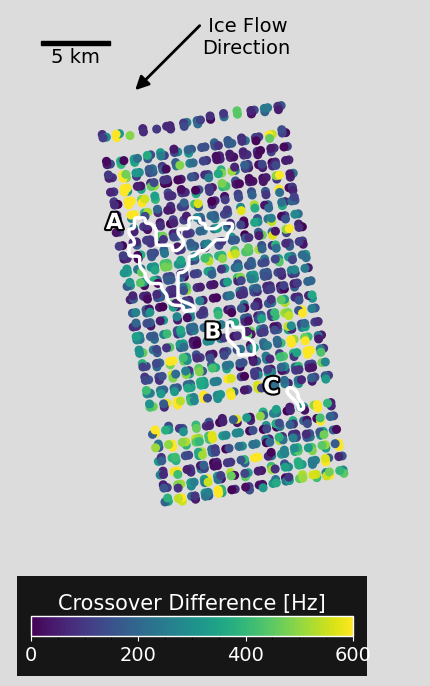

In [140]:
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

# Remove borders
ax.patch.set_facecolor("none")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

for x, y in zip(xs_lake, ys_lake):
    ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

# Add colorbar
k_cbar_anchor = (0,0)
cbbox = inset_axes(ax, width=3.5,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax.transAxes, loc="center left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.9])

cb = ax.scatter(x_cross, y_cross, c=ridge_diff_velocity_corrected_1819, cmap='viridis', s=30, zorder=4,vmin=0,vmax=600) # Dummy scatter for colorbar
cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"Crossover Difference [Hz]", fontsize=15, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
#ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)


# Lakeb lakes A, B, C
ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')

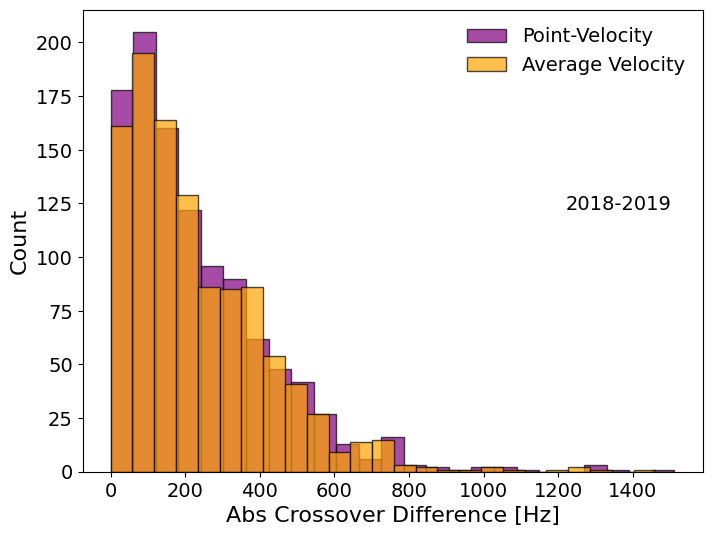

In [149]:
# Hist of absolute ridge difference
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(ridge_diff_velocity_corrected_1819, bins=25, color='purple',alpha=0.7, edgecolor='black')
ax.hist(ridge_diff_1819, bins=25, color='orange',alpha=0.7, edgecolor='black')
# Boxplot
#ax.boxplot(abs_ridge_diff, vert=False, patch_artist=True, boxprops=dict(facecolor='purple', color='black'), medianprops=dict(color='yellow'))
ax.set_xlabel('Abs Crossover Difference [Hz]', fontsize=16)
ax.set_ylabel('Count', fontsize=16)
ax.tick_params(labelsize=14)
ax.text(0.95, 0.6, f'2018-2019', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='right')

ax.legend(['Point-Velocity', 'Average Velocity'], fontsize=14, loc='upper right', frameon=False)

In [150]:
# Crossover error with self
coords = []
width = []
width_velocity_corrected = []
line_id = []

for i, (xs, ys, ridge_list, velocity) in enumerate(zip(
        plotting_dict['x_centers'],
        plotting_dict['y_centers'],
        plotting_dict['ridge_params_list'],
        plotting_dict['velocities'])):

    n = len(xs)

    coords.append(np.column_stack((xs, ys)))
    # Extend by the width of each ridge, scaled by velocity
    width_velocity_corrected.extend([abs(r['left'] - r['right']) * velocity[j] for j, r in enumerate(ridge_list)])
    avg_velocity = np.mean(velocity)
    width.extend([abs(r['left'] - r['right'])*avg_velocity for r in ridge_list])
    line_id.extend([i]*n)

coords = np.vstack(coords)
width = np.array(width)
width_velocity_corrected = np.array(width_velocity_corrected)
line_id = np.array(line_id)

tree = cKDTree(coords)

pairs = np.array(list(tree.query_pairs(r=500)))

i, j = pairs[:,0], pairs[:,1]

mask = line_id[i] != line_id[j]

i = i[mask]
j = j[mask]

ridge_diff_1617 = np.abs(width[i] - width[j])
ridge_diff_velocity_corrected_1617 = np.abs(width_velocity_corrected[i] - width_velocity_corrected[j])

coords_i = coords[i]
coords_j = coords[j]

x_cross = (coords[i,0] + coords[j,0]) / 2
y_cross = (coords[i,1] + coords[j,1]) / 2



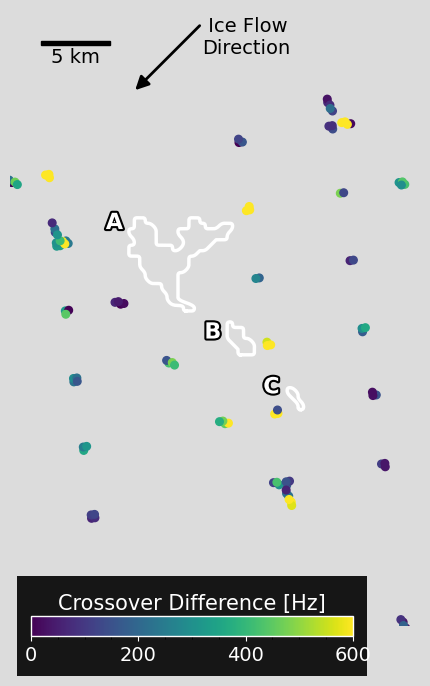

In [132]:
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

# Remove borders
ax.patch.set_facecolor("none")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

for x, y in zip(xs_lake, ys_lake):
    ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

# Add colorbar
k_cbar_anchor = (0,0)
cbbox = inset_axes(ax, width=3.5,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax.transAxes, loc="center left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.9])

cb = ax.scatter(x_cross, y_cross, c=abs_ridge_diff_1617, cmap='viridis', s=30, zorder=4,vmin=0,vmax=600) # Dummy scatter for colorbar
cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"Crossover Difference [Hz]", fontsize=15, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
#ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)


# Lakeb lakes A, B, C
ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')

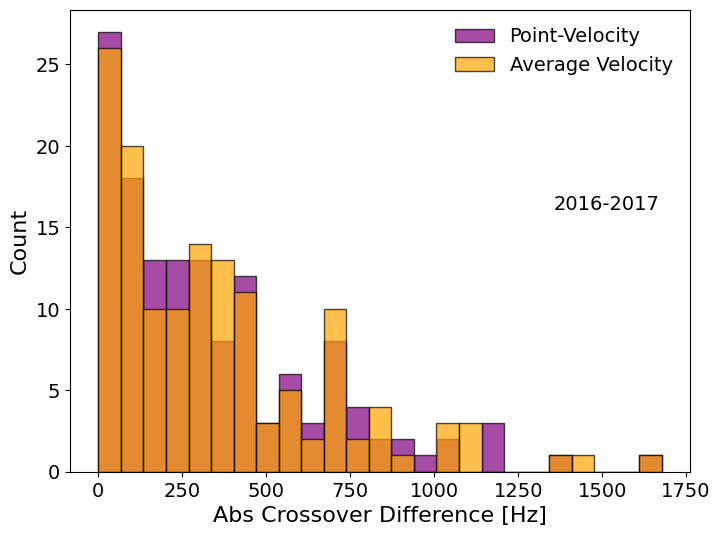

In [155]:
# Hist of absolute ridge difference
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(ridge_diff_velocity_corrected_1617, bins=25, color='purple',alpha=0.7, edgecolor='black')
ax.hist(ridge_diff_1617, bins=25, color='orange',alpha=0.7, edgecolor='black')
# Boxplot
#ax.boxplot(abs_ridge_diff, vert=False, patch_artist=True, boxprops=dict(facecolor='purple', color='black'), medianprops=dict(color='yellow'))
ax.set_xlabel('Abs Crossover Difference [Hz]', fontsize=16)
ax.set_ylabel('Count', fontsize=16)
ax.tick_params(labelsize=14)
ax.text(0.95, 0.6, f'2016-2017', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='right')

ax.legend(['Point-Velocity', 'Average Velocity'], fontsize=14, loc='upper right', frameon=False)